In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import numpy as np




In [18]:
#Subimos la base de datos
df = pd.read_csv('/content/properati-MX-2017-07-01-properties-sell.csv', encoding='ISO-8859-1', engine='python', on_bad_lines='skip')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128524 entries, 0 to 128523
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          128524 non-null  object 
 1   created_on                  128524 non-null  object 
 2   operation                   128524 non-null  object 
 3   property_type               128524 non-null  object 
 4   place_name                  128524 non-null  object 
 5   place_with_parent_names     128524 non-null  object 
 6   country_name                128524 non-null  object 
 7   state_name                  128524 non-null  object 
 8   geonames_id                 0 non-null       float64
 9   lat-lon                     81280 non-null   object 
 10  lat                         81280 non-null   float64
 11  lon                         81280 non-null   float64
 12  price                       126950 non-null  float64
 13  currency      

In [19]:
# Usamos .str.contains para que busque "Puebla" sin importar lo que haya antes o después
df_puebla = df[df['place_with_parent_names'].str.contains('Puebla', na=False)].copy()
len(df_puebla)

6855

In [20]:
#Renombramos columnas
df_puebla = df_puebla.rename(columns={
    'surface_total_in_m2': 'superficie_total',
    'surface_covered_in_m2': 'superficie_cubierta',
    'floor': 'pisos',
    'rooms': 'cuartos',
    'price_aprox_local_currency': 'precio_mxn'
})


In [21]:
#Eliminamos las columnas que no usamos
v_interes = ['precio_mxn', 'superficie_total', 'superficie_cubierta', 'pisos', 'cuartos','lat', 'lon']
df_puebla = df_puebla[v_interes].copy()
df_puebla

,precio_mxn,superficie_total,superficie_cubierta,pisos,cuartos,lat,lon
31,4740045.30,NaN,282.0,NaN,NaN,19.010921,-98.246630
32,5748565.65,NaN,302.0,NaN,NaN,19.010839,-98.246819
38,2107807.26,NaN,148.0,NaN,NaN,19.077450,-98.225258
102,2975134.77,NaN,215.0,NaN,NaN,19.082069,-98.229803
199,3065901.51,NaN,84.0,NaN,NaN,19.044477,-98.328011
...,...,...,...,...,...,...,...
128406,4831828.07,200.0,260.0,NaN,NaN,19.044477,-98.328011
128425,1861525.23,92.0,185.0,NaN,NaN,18.989595,-98.203529
128520,18105233.82,NaN,757.0,NaN,NaN,19.068563,-98.249389
128521,1810523.38,120.0,140.0,NaN,3.0,18.984174,-98.190779


In [22]:
# Eliminamos filas sin precio (nuestra Y),sin superficie, y sin lat y lon,(nuestra X principal)
df_puebla = df_puebla.dropna(subset=['precio_mxn', 'superficie_total', 'superficie_cubierta','lat','lon'	])
len(df_puebla)

1014

In [23]:
# Para baños y recámaras, podemos rellenar con 1s
df_puebla['cuartos'] = df_puebla['cuartos'].fillna(1)
df_puebla['pisos'] = df_puebla['pisos'].fillna(1)

/tmp/ipykernel_2411/4273566625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_puebla['cuartos'] = df_puebla['cuartos'].fillna(1)
/tmp/ipykernel_2411/4273566625.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_puebla['pisos'] = df_puebla['pisos'].fillna(1)


In [24]:
#Filtro de Outliers (Valores atípicos)
# Quitamos "ruido": Precios menores a 300k o mayores a 20M, y superficies irreales
df_puebla = df_puebla[(df_puebla['precio_mxn'] > 300000) & (df_puebla['precio_mxn'] < 20000000)]
df_puebla = df_puebla[(df_puebla['superficie_total'] > 35) & (df_puebla['superficie_total'] < 1000)]
df_puebla = df_puebla[(df_puebla['superficie_cubierta'] > 35) & (df_puebla['superficie_cubierta'] < 1000)]

In [25]:
df_puebla = df_puebla[(df_puebla['superficie_total'] > 0) & (df_puebla['precio_mxn'] > 0)]
df_puebla

,precio_mxn,superficie_total,superficie_cubierta,pisos,cuartos,lat,lon
638,4018046.42,174.0,312.0,1.0,1.0,18.964255,-98.289796
675,3356848.90,135.0,245.0,1.0,1.0,19.044477,-98.328011
693,1322395.03,90.0,90.0,1.0,1.0,19.066868,-98.282498
722,1780147.09,170.0,170.0,1.0,1.0,19.083184,-98.319795
1013,5391302.77,168.0,330.0,1.0,1.0,19.044477,-98.328011
...,...,...,...,...,...,...,...
128355,610336.01,67.0,63.0,1.0,1.0,18.994194,-98.249329
128357,2242985.31,163.0,163.0,1.0,1.0,19.067272,-98.312950
128406,4831828.07,200.0,260.0,1.0,1.0,19.044477,-98.328011
128425,1861525.23,92.0,185.0,1.0,1.0,18.989595,-98.203529


In [26]:
df_final=df_puebla

In [27]:
print(f"Limpieza terminada. Registros finales de Puebla: {len(df_final)}")

Limpieza terminada. Registros finales de Puebla: 795


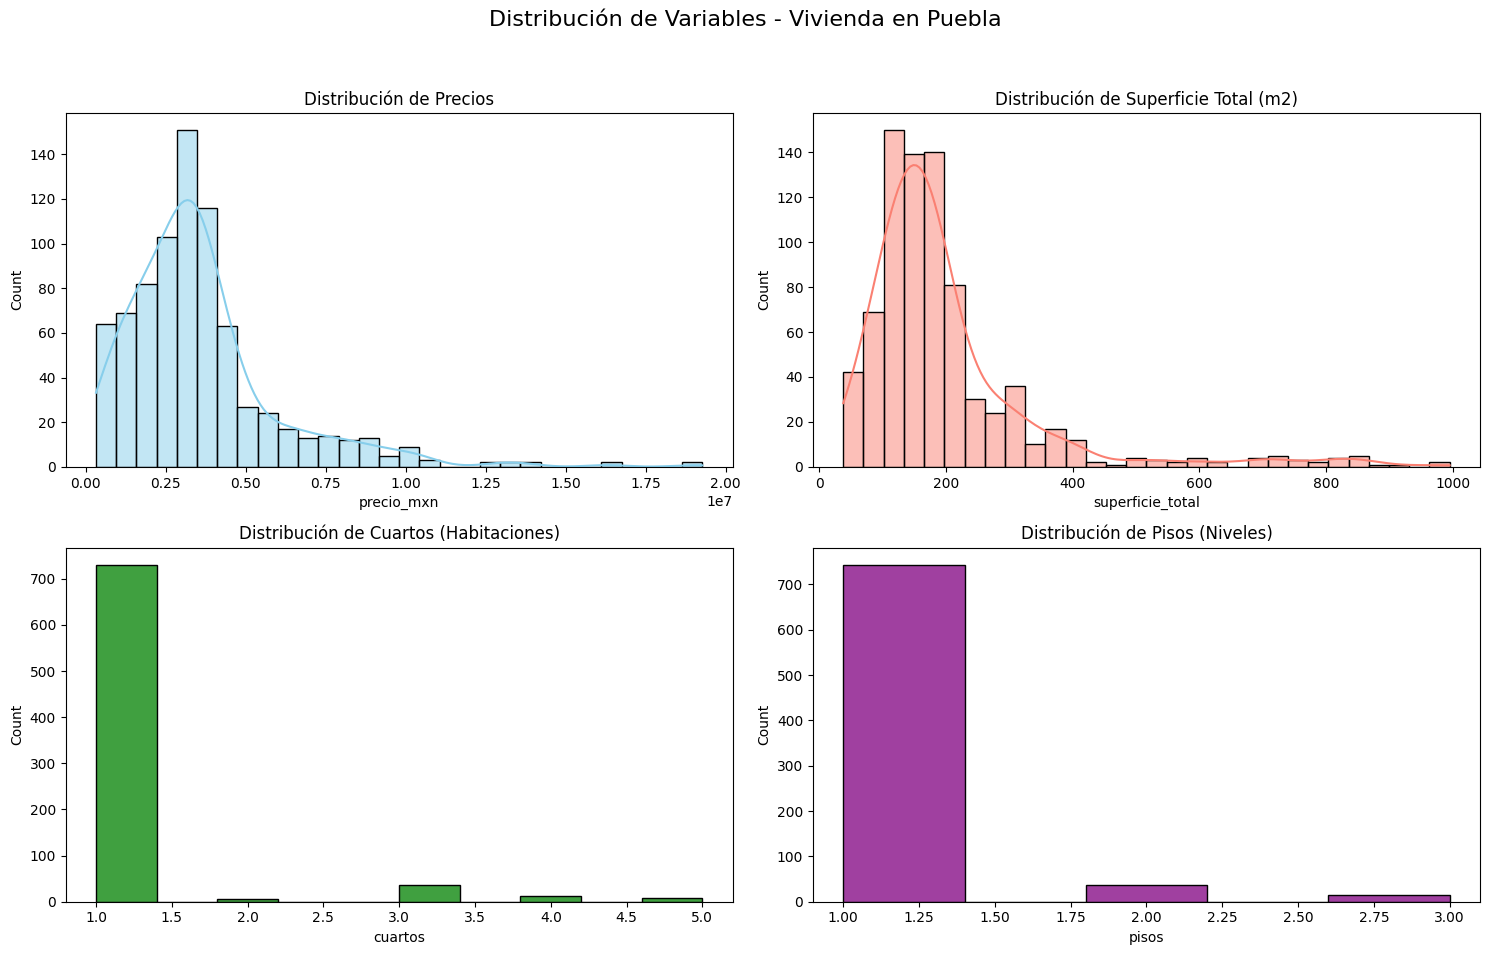

In [28]:
# Configuramos el estilo y el tamaño de la figura
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Variables - Vivienda en Puebla', fontsize=16)

# 1. Histograma de Precios (Y)
sns.histplot(df_final['precio_mxn'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Precios')

# 2. Histograma de Superficie (X1)
sns.histplot(df_final['superficie_total'], bins=30, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribución de Superficie Total (m2)')

# 3. Histograma de Cuartos (X2)
sns.histplot(df_final['cuartos'], bins=10, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribución de Cuartos (Habitaciones)')

# 4. Histograma de Pisos (X3)
sns.histplot(df_final['pisos'], bins=5, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribución de Pisos (Niveles)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
# ESTADÍSTICOS, CORRELACIONES Y BOXPLOTS

# Revisión de valores faltantes final
print(" Valores Faltantes ")
print(df_final.isnull().sum())
print("\n")

# Estadísticos descriptivos
print("Estadísticos Descriptivos")
display(df_final.describe())


 Valores Faltantes 
precio_mxn             0
superficie_total       0
superficie_cubierta    0
pisos                  0
cuartos                0
lat                    0
lon                    0
dtype: int64


Estadísticos Descriptivos


,precio_mxn,superficie_total,superficie_cubierta,pisos,cuartos,lat,lon
count,7.950000e+02,795.000000,795.000000,795.000000,795.000000,795.000000,795.000000
mean,3.580235e+06,201.184906,240.851572,1.081761,1.189937,19.089338,-98.322035
std,2.454202e+06,145.988595,120.820581,0.332318,0.682933,0.516362,0.481566
min,3.153402e+05,38.000000,36.000000,1.000000,1.000000,18.897264,-102.552784
25%,2.034454e+06,124.500000,159.500000,1.000000,1.000000,18.993210,-98.322533
50%,3.231730e+06,165.000000,230.000000,1.000000,1.000000,19.044477,-98.276822
75%,4.267671e+06,210.000000,292.000000,1.000000,1.000000,19.059122,-98.234535
max,1.927645e+07,995.000000,850.000000,3.000000,5.000000,23.634501,-97.827278


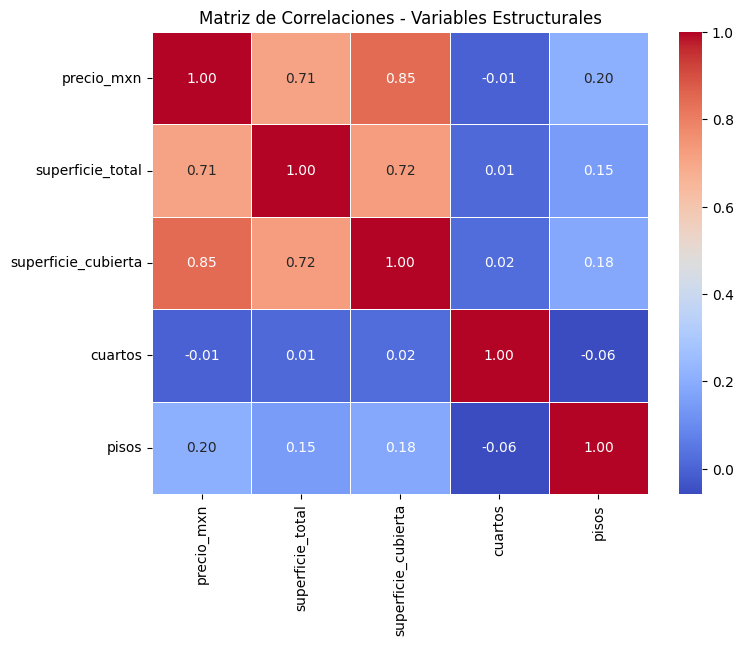

In [30]:

# Matriz de correlaciones
plt.figure(figsize=(8, 6))
# Dejamos fuera lat y lon para enfocarnos en las características del inmueble
v_corr = ['precio_mxn', 'superficie_total', 'superficie_cubierta', 'cuartos', 'pisos']
matriz_corr = df_final[v_corr].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlaciones - Variables Estructurales')
plt.show()



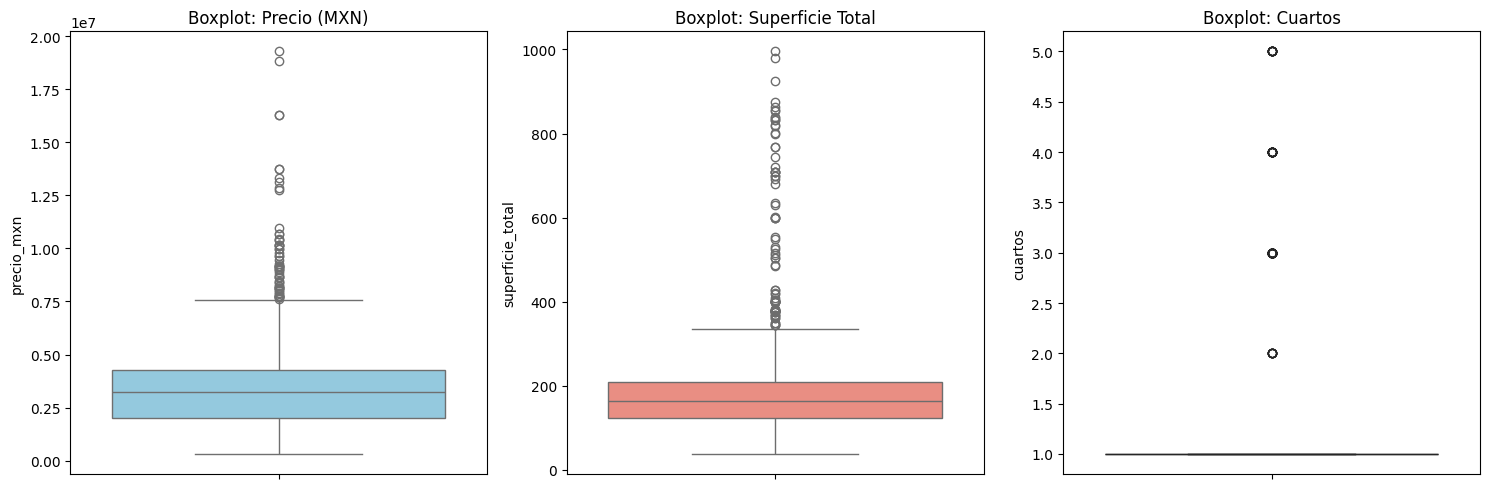

In [31]:
# Distribuciones mediante Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_final['precio_mxn'], ax=axes[0], color='skyblue').set_title('Boxplot: Precio (MXN)')
sns.boxplot(y=df_final['superficie_total'], ax=axes[1], color='salmon').set_title('Boxplot: Superficie Total')
sns.boxplot(y=df_final['cuartos'], ax=axes[2], color='green').set_title('Boxplot: Cuartos')
plt.tight_layout()
plt.show()

In [31]:
df_final.to_excel('df_final.xlsx', index=False)
print('DataFrame df_final has been saved to df_final.xlsx')